<a href="https://colab.research.google.com/github/iav2002/Assignment_Advanced_Topics_In_DeepLearning/blob/main/Part2-linearProbing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 2 - Training Experiments

This notebook runs all training experiments for Part 2. The data pipeline
is built in the exploration; here we copy the minimal pieces needed and focus
on the modeling experiments.

Experiments planned (just trying small models right now, will change later):
1. Linear probing — ResNet18 (this session)
2. Full fine-tune — ResNet18
3. Linear probing — ViT-Small
4. Full fine-tune — ViT-Small
5. Gradual unfreezing — best backbone
6. LoRA sweep — ResNet18 + ViT-Small
7. Differential learning rates — full fine-tune variant

In [ ]:
# timm = pytorch-image-models, the standard library for modern vision backbones
# installs quickly, colab does not have it pre-installed
#!pip install -q timm

In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

# standard library
import os
import json
import random
import time
from pathlib import Path
from collections import Counter

# third-party
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from pycocotools.coco import COCO
import timm

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# device setup -- use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: NVIDIA L4
Memory: 23.7 GB


In [ ]:
# paths -- same as the data pipeline notebook
DRIVE_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/AdvancedDL')
DATA_ROOT = DRIVE_ROOT / 'coco'
RESULTS_ROOT = DRIVE_ROOT / 'results'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

IMG_DIRS = {
    'train': DATA_ROOT / 'images' / 'train',
    'val':   DATA_ROOT / 'images' / 'val',
    'test':  DATA_ROOT / 'images' / 'test',
}
ANN_FILES = {
    'train': DATA_ROOT / 'annotations' / 'instances_train.json',
    'val':   DATA_ROOT / 'annotations' / 'instances_val.json',
    'test':  DATA_ROOT / 'annotations' / 'instances_test.json',
}

# preprocessing constants
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMG_SIZE = 224
MIN_BOX_SIDE = 20

In [ ]:
# load coco objects for all splits
cocos = {split: COCO(str(ANN_FILES[split])) for split in ['train', 'val', 'test']}

# define class vocabulary -- all 25 classes, ordered by train frequency
def class_counts(coco_obj):
    counts = Counter()
    for ann_id in coco_obj.getAnnIds():
        ann = coco_obj.loadAnns([ann_id])[0]
        name = coco_obj.loadCats(ann['category_id'])[0]['name']
        counts[name] += 1
    return counts

counts_train = class_counts(cocos['train'])
all_classes = [name for name, _ in counts_train.most_common()]

CLASS_TO_IDX = {name: i for i, name in enumerate(all_classes)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}
NUM_CLASSES = len(all_classes)
print(f'Num classes: {NUM_CLASSES}')


# build flat sample lists per split
def build_samples(coco_obj, img_dir, class_to_idx, min_side):
    cat_id_to_name = {c['id']: c['name'] for c in coco_obj.loadCats(coco_obj.getCatIds())}
    samples = []
    for ann_id in coco_obj.getAnnIds():
        ann = coco_obj.loadAnns([ann_id])[0]
        name = cat_id_to_name[ann['category_id']]
        if name not in class_to_idx:
            continue
        x, y, w, h = ann['bbox']
        if min(w, h) < min_side:
            continue
        img_info = coco_obj.loadImgs([ann['image_id']])[0]
        samples.append({
            'img_path': str(img_dir / img_info['file_name']),
            'bbox': [x, y, w, h],
            'label': class_to_idx[name],
            'class_name': name,
        })
    return samples

samples = {
    split: build_samples(cocos[split], IMG_DIRS[split], CLASS_TO_IDX, MIN_BOX_SIDE)
    for split in ['train', 'val', 'test']
}

for split, s in samples.items():
    print(f'{split}: {len(s)} samples')

loading annotations into memory...
Done (t=0.18s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Num classes: 25
train: 39592 samples
val: 8525 samples
test: 8570 samples


In [ ]:
class WarehouseCropDataset(Dataset):
    """yields (cropped image tensor, label) for one bbox at a time"""

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self._img_cache = {}

    def __len__(self):
        return len(self.samples)

    def _load_image(self, path):
        if path in self._img_cache:
            return self._img_cache[path]
        img = Image.open(path).convert('RGB')
        self._img_cache = {path: img}
        return img

    def __getitem__(self, idx):
        s = self.samples[idx]
        img = self._load_image(s['img_path'])
        x, y, w, h = s['bbox']
        crop = img.crop((x, y, x + w, y + h))
        if self.transform is not None:
            crop = self.transform(crop)
        return crop, s['label']


# basic transforms -- resize + normalize with imagenet stats
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# datasets
train_ds = WarehouseCropDataset(samples['train'], transform=basic_transform)
val_ds   = WarehouseCropDataset(samples['val'], transform=basic_transform)
test_ds  = WarehouseCropDataset(samples['test'], transform=basic_transform)

# dataloaders
# num_workers=2 speeds up data loading by using parallel workers
# pin_memory=True helps gpu transfer
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')

Batches: train=619, val=134, test=134


In [ ]:
import shutil

# copy images from drive to local disk for faster loading
# this is a one-time cost at session start, but makes every epoch 10x+ faster

LOCAL_DATA = Path('/content/coco_images')
LOCAL_DATA.mkdir(parents=True, exist_ok=True)

for split in ['train', 'val', 'test']:
    src = IMG_DIRS[split]
    dst = LOCAL_DATA / split
    if dst.exists() and len(list(dst.iterdir())) > 0:
        print(f'{split}: already copied ({len(list(dst.iterdir()))} files)')
        continue
    print(f'Copying {split} images from drive to local disk...')
    t0 = time.time()
    shutil.copytree(src, dst)
    print(f'  done in {time.time()-t0:.1f}s, {len(list(dst.iterdir()))} files')

# now rewrite the sample paths to point to the local copies
def rewrite_path(sample):
    # original: /content/drive/MyDrive/.../coco/images/train/warehouse_001.png
    # new:      /content/coco_images/train/warehouse_001.png
    old_path = Path(sample['img_path'])
    split_name = old_path.parent.name  # 'train', 'val', or 'test'
    file_name = old_path.name
    sample['img_path'] = str(LOCAL_DATA / split_name / file_name)
    return sample

for split in ['train', 'val', 'test']:
    samples[split] = [rewrite_path(s) for s in samples[split]]

# rebuild datasets and loaders with the new paths
train_ds = WarehouseCropDataset(samples['train'], transform=basic_transform)
val_ds   = WarehouseCropDataset(samples['val'], transform=basic_transform)
test_ds  = WarehouseCropDataset(samples['test'], transform=basic_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Loaders rebuilt with local paths. Train batches: {len(train_loader)}')

Copying train images from drive to local disk...
  done in 174.9s, 4654 files
Copying val images from drive to local disk...
  done in 69.1s, 1125 files
Copying test images from drive to local disk...
  done in 44.1s, 1124 files
Loaders rebuilt with local paths. Train batches: 619


## Training helpers

Reusable functions for the training loop. We'll call these for every experiment.

In [ ]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    # wrap the loader in tqdm to see progress
    pbar = tqdm(loader, desc='train', leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # update progress bar with current metrics
        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total:.4f}')

    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """run over a loader in eval mode and return avg loss + accuracy"""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def count_trainable_params(model):
    """count how many parameters will actually be updated by the optimizer"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## Experiment 1: Linear Probing — ResNet18

Linear probing freezes the entire pretrained backbone and trains only a new
classification head. It measures how good the ImageNet-learned features are
for our task, without modifying them.

**Hypothesis:** ResNet18's ImageNet features should be decent but not great for
warehouse objects. Expect val accuracy in the 50-70% range.

In [ ]:
# load resnet18 pretrained on imagenet, with a new classification head for our 25 classes
# timm handles replacing the final fc layer automatically when num_classes is passed
model = timm.create_model('resnet18', pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

# freeze everything first
for p in model.parameters():
    p.requires_grad = False

# unfreeze only the classification head (the final fc layer in resnet)
# timm exposes .get_classifier() which returns the head regardless of architecture
for p in model.get_classifier().parameters():
    p.requires_grad = True

# verify: count trainable vs total
trainable = count_trainable_params(model)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

Trainable params: 12,825 / 11,189,337 (0.11%)


In [ ]:
# config for this experiment
EXP_NAME = 'linprobe_resnet18'
EPOCHS = 5
LR = 1e-3   # higher lr for linear probing since we only train the head

# loss and optimizer -- only pass the trainable parameters to the optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=1e-4
)

print(f'Experiment: {EXP_NAME}')
print(f'Epochs: {EPOCHS}, LR: {LR}, Batch: {BATCH_SIZE}')
print(f'Optimizer: AdamW, Criterion: CrossEntropyLoss')

Experiment: linprobe_resnet18
Epochs: 5, LR: 0.001, Batch: 64
Optimizer: AdamW, Criterion: CrossEntropyLoss


In [ ]:
# training loop -- track metrics per epoch and save best model
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0
start_time = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - t0
    print(f'Epoch {epoch+1}/{EPOCHS} | '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
          f'val_loss={val_loss:.4f} val_acc={val_acc:.4f} | '
          f'time={epoch_time:.1f}s')

    # save checkpoint if this is the best val accuracy so far
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        exp_dir = RESULTS_ROOT / EXP_NAME
        exp_dir.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), exp_dir / 'best_model.pt')
        print(f'  -> saved new best (val_acc={val_acc:.4f})')

total_time = time.time() - start_time
print(f'\nTotal training time: {total_time:.1f}s ({total_time/60:.1f} min)')
print(f'Best val accuracy: {best_val_acc:.4f}')

train:   0%|          | 0/619 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=2.5187 train_acc=0.2519 | val_loss=2.3024 val_acc=0.3342 | time=281.7s
  -> saved new best (val_acc=0.3342)


train:   0%|          | 0/619 [00:00<?, ?it/s]

Epoch 2/5 | train_loss=2.2002 train_acc=0.3631 | val_loss=2.1148 val_acc=0.3974 | time=281.3s
  -> saved new best (val_acc=0.3974)


train:   0%|          | 0/619 [00:00<?, ?it/s]

Epoch 3/5 | train_loss=2.0479 train_acc=0.4112 | val_loss=2.0008 val_acc=0.4252 | time=282.9s
  -> saved new best (val_acc=0.4252)


train:   0%|          | 0/619 [00:00<?, ?it/s]

Epoch 4/5 | train_loss=1.9506 train_acc=0.4400 | val_loss=1.9241 val_acc=0.4432 | time=281.7s
  -> saved new best (val_acc=0.4432)


train:   0%|          | 0/619 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=1.8756 train_acc=0.4631 | val_loss=1.8605 val_acc=0.4680 | time=287.1s
  -> saved new best (val_acc=0.4680)

Total training time: 1415.4s (23.6 min)
Best val accuracy: 0.4680


In [ ]:
# load the best model (best val accuracy, not necessarily last epoch)
exp_dir = RESULTS_ROOT / EXP_NAME
model.load_state_dict(torch.load(exp_dir / 'best_model.pt'))

# evaluate on test set
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test accuracy: {test_acc:.4f}')

# save the full results dict
results = {
    'experiment': EXP_NAME,
    'config': {
        'model': 'resnet18',
        'method': 'linear_probing',
        'epochs': EPOCHS,
        'lr': LR,
        'batch_size': BATCH_SIZE,
        'trainable_params': trainable,
        'total_params': total,
    },
    'history': history,
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
    'training_time_seconds': total_time,
}
with open(exp_dir / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'Results saved to {exp_dir}/results.json')

Test accuracy: 0.4749
Results saved to /content/drive/MyDrive/Colab Notebooks/AdvancedDL/results/linprobe_resnet18/results.json


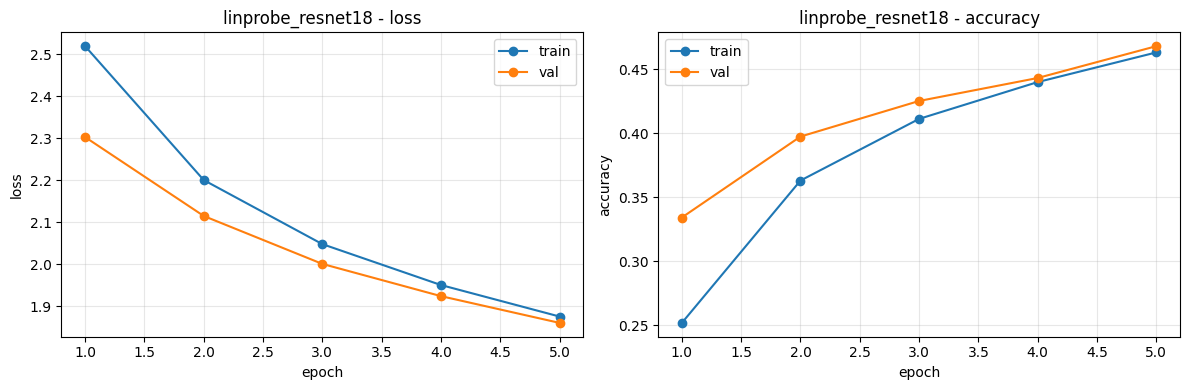

In [ ]:
# plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, EPOCHS + 1)
axes[0].plot(epochs_range, history['train_loss'], label='train', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='val', marker='o')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title(f'{EXP_NAME} - loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], label='train', marker='o')
axes[1].plot(epochs_range, history['val_acc'],   label='val', marker='o')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title(f'{EXP_NAME} - accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()